# Loading the dataset

In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("mariusmarin/bs-80k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bs-80k' dataset.
Path to dataset files: /kaggle/input/bs-80k


In [ ]:
import os

# The user identified 'temp' as the main dataset folder for the BS-80K images
dataset_root = os.path.join(path, 'temp')

if os.path.exists(dataset_root):
    print(f"Exploring dataset root: {dataset_root}")

    # List subdirectories to understand the structure (e.g., categories of metastases)
    subdirs = [d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))]
    print(f"Subdirectories found: {subdirs}")

    # Count files in the first few subdirectories to verify images
    for subdir in subdirs[:5]:
        subdir_path = os.path.join(dataset_root, subdir)
        img_count = len([f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
        print(f"- {subdir}: {img_count} images found")
else:
    print(f"The directory {dataset_root} does not exist. Current path contents: {os.listdir(path)}")

Exploring dataset root: /kaggle/input/bs-80k/temp
Subdirectories found: ['ankleRPOST', 'kneeRPOST', 'vertbraANT', 'ankleLANT', 'chestLPOST', 'kneeLANT', 'headPOST', 'wholeBodyPOST', 'kneeLPOST', 'chestRANT', 'vertbraPOST', 'headANT', 'pelvisPOST', 'elbowRANT', 'wholeBodyANT', 'shoLANT', 'elbowRPOST', 'chestLANT', 'shoRPOST', 'ankleRANT', 'ankleLPOST', 'kneeRANT', 'shoLPOST', 'elbowLPOST', 'chestRPOST', 'elbowLANT', 'pelvisANT', 'shoRANT']
- ankleRPOST: 2925 images found
- kneeRPOST: 2925 images found
- vertbraANT: 2925 images found
- ankleLANT: 2925 images found
- chestLPOST: 2925 images found


In [ ]:
import os
import pandas as pd

# Configuration
dataset_root = os.path.join(path, 'temp')
all_data = []

# Iterate through each subdirectory to collect labels and paths
subdirs = [d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))]

for subdir in subdirs:
    subdir_path = os.path.join(dataset_root, subdir)
    txt_file_path = os.path.join(subdir_path, f"{subdir}.txt")

    if os.path.exists(txt_file_path):
        try:
            # Use raw string r'\s+'
            labels_df = pd.read_csv(txt_file_path, sep=r'\s+', names=['filename', 'label'], header=None)

            # Enrich metadata
            labels_df['folder'] = subdir
            labels_df['full_path'] = labels_df['filename'].apply(lambda x: os.path.join(subdir_path, x))

            all_data.append(labels_df)
        except Exception as e:
            print(f"Error reading {txt_file_path}: {e}")

# Combine into master DataFrame
if all_data:
    dataset_df = pd.concat(all_data, ignore_index=True)
    print(f"Dataset loaded with {len(dataset_df)} labeled images.")

    # Display summary statistics
    display(dataset_df.head())
    print("\nLabel distribution (0=Normal, 1=Abnormal):")
    display(dataset_df['label'].value_counts())
else:
    print("No label files were found. Please check the dataset path.")

Dataset loaded with 82545 labeled images.


,filename,label,folder,full_path
0,1000.jpg,0,ankleRPOST,/kaggle/input/bs-80k/temp/ankleRPOST/1000.jpg
1,1001.jpg,0,ankleRPOST,/kaggle/input/bs-80k/temp/ankleRPOST/1001.jpg
2,1002.jpg,0,ankleRPOST,/kaggle/input/bs-80k/temp/ankleRPOST/1002.jpg
3,1003.jpg,0,ankleRPOST,/kaggle/input/bs-80k/temp/ankleRPOST/1003.jpg
4,1004.jpg,0,ankleRPOST,/kaggle/input/bs-80k/temp/ankleRPOST/1004.jpg



Label distribution (0=Normal, 1=Abnormal):


,count
label,
0,76749
1,5796


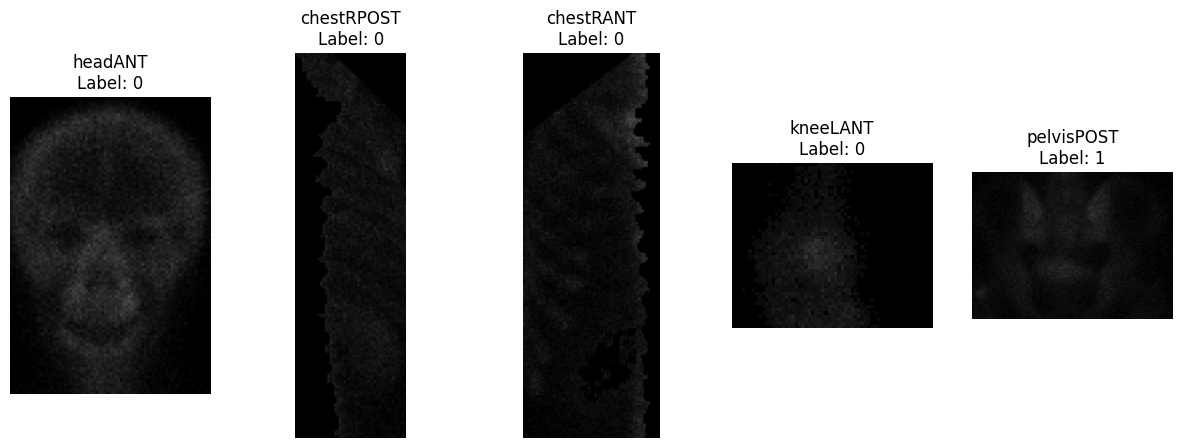

In [ ]:
import matplotlib.pyplot as plt
import cv2

def show_samples(df, n=5):
    plt.figure(figsize=(15, 5))
    samples = df.sample(n)
    for i, (idx, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row['full_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{row['folder']}\nLabel: {row['label']}")
        plt.axis('off')
    plt.show()

# Show some random samples from the loaded dataset
if not dataset_df.empty:
    show_samples(dataset_df)

# Preprocessing

###Phase 1: Noise Reduction and Contrast Enhancement
We apply a Median Filter for denoising and CLAHE for localized contrast improvement.

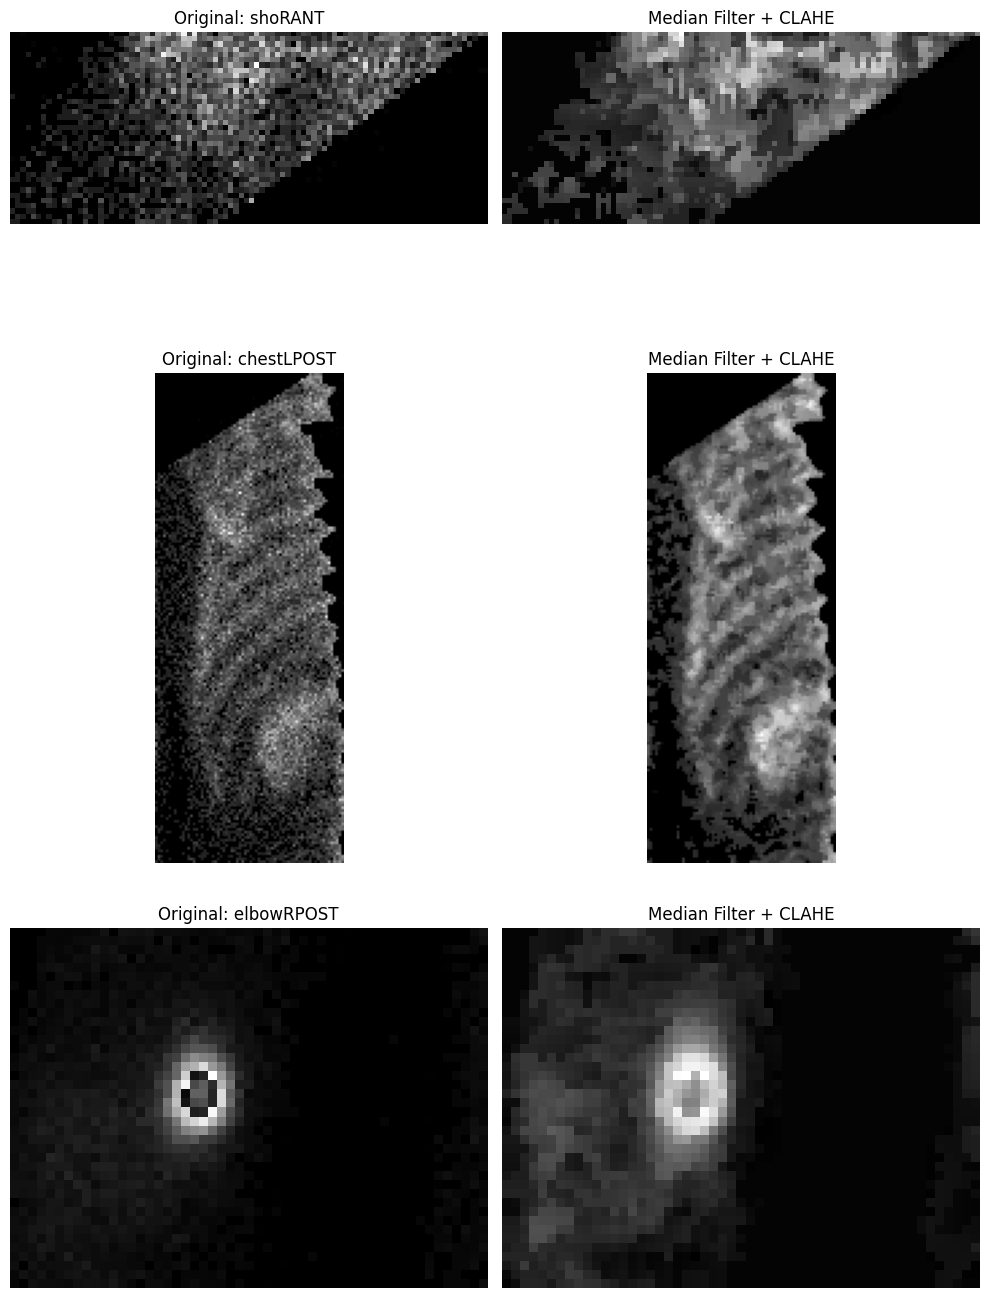

In [ ]:
import numpy as np

def preprocess_image(img_path):
    # Load image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # 1. Noise Reduction: Median Filter
    denoised = cv2.medianBlur(img, 3)

    # 2. Contrast Enhancement: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    return img, enhanced

# Visualize the effect on a few samples
samples = dataset_df.sample(3)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i, (idx, row) in enumerate(samples.iterrows()):
    original, processed = preprocess_image(row['full_path'])

    axes[i, 0].imshow(original, cmap='gray')
    axes[i, 0].set_title(f"Original: {row['folder']}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(processed, cmap='gray')
    axes[i, 1].set_title("Median Filter + CLAHE")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

### Phase 2: Resizing & Region Cropping

In this phase, we implement methods to prepare images for model input while preserving anatomical aspect ratios and enabling localized analysis through slicing.

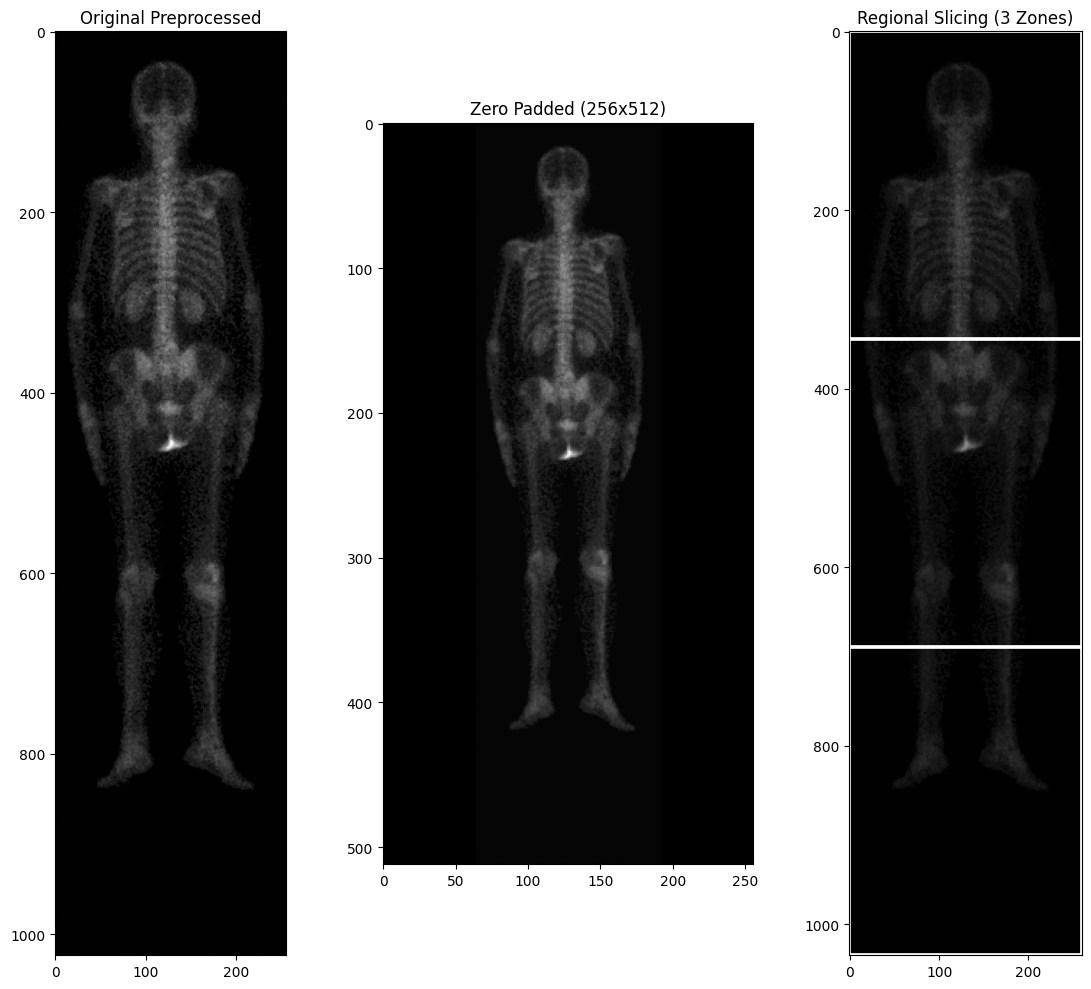

In [ ]:
def resize_with_padding(img, target_size=(224, 224)):
    """Resizes image keeping aspect ratio by adding zero padding."""
    h, w = img.shape[:2]
    target_w, target_h = target_size

    # Calculate scale
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)

    # Resize image
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Create canvas and paste resized image
    canvas = np.zeros((target_h, target_w), dtype=np.uint8)
    top = (target_h - new_h) // 2
    left = (target_w - new_w) // 2
    canvas[top:top+new_h, left:left+new_w] = resized

    return canvas

def slice_image(img, rows=2, cols=2):
    """Slices the image into a grid of patches for regional analysis."""
    h, w = img.shape[:2]
    patch_h, patch_w = h // rows, w // cols
    patches = []

    for i in range(rows):
        for j in range(cols):
            patch = img[i*patch_h:(i+1)*patch_h, j*patch_w:(j+1)*patch_w]
            patches.append(patch)

    return patches

# --- Demonstration with a Whole Body Scan ---
# Find a wholeBody scan for better demonstration of slicing
wb_sample = dataset_df[dataset_df['folder'].str.contains('wholeBody', case=False)].iloc[0]
_, enhanced = preprocess_image(wb_sample['full_path'])

# 1. Padding Demo
padded = resize_with_padding(enhanced, (256, 512))

# 2. Slicing Demo (e.g., Head, Thorax, Pelvis, Legs)
patches = slice_image(enhanced, rows=3, cols=1)

# Visualization
plt.figure(figsize=(12, 10))
plt.subplot(1, 3, 1)
plt.imshow(enhanced, cmap='gray')
plt.title("Original Preprocessed")

plt.subplot(1, 3, 2)
plt.imshow(padded, cmap='gray')
plt.title("Zero Padded (256x512)")

plt.subplot(1, 3, 3)
# Show patches stacked vertically for the WB scan
combined_patches = np.vstack([cv2.copyMakeBorder(p, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=255) for p in patches])
plt.imshow(combined_patches, cmap='gray')
plt.title("Regional Slicing (3 Zones)")

plt.tight_layout()
plt.show()

### Phase 3: Handling Multi-View Inputs

In bone scans, having both Anterior (ANT) and Posterior (POST) views is standard. We will implement Early Fusion (channel stacking) and Late Fusion (feature merging).

Paired scans found: 2925
Early Fusion Shape: (224, 224, 2)


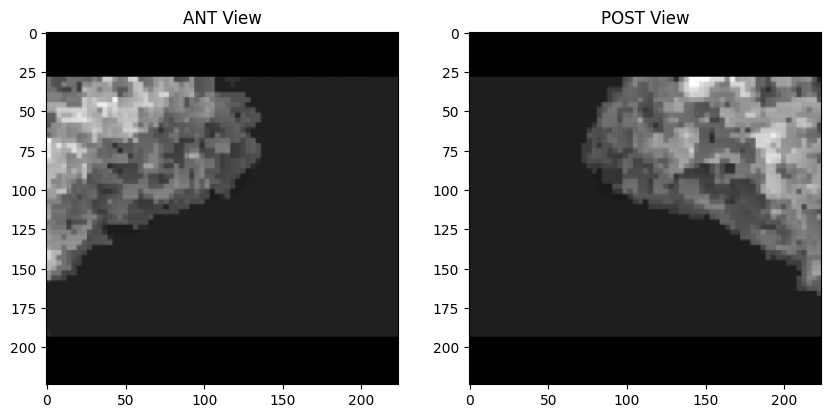

In [ ]:
def get_paired_views(df, folder_base):
    """
    Groups ANT and POST views for the same patient/scan session.
    Example: 'ankleRANT' and 'ankleRPOST'
    """
    ant_folder = folder_base + 'ANT'
    post_folder = folder_base + 'POST'

    ant_df = df[df['folder'] == ant_folder].copy()
    post_df = df[df['folder'] == post_folder].copy()

    # Merge on filename assuming 1000.jpg in ANT corresponds to 1000.jpg in POST
    paired = pd.merge(ant_df, post_df, on='filename', suffixes=('_ANT', '_POST'))
    return paired

def early_fusion_stack(img_ant, img_post):
    """Stacks ANT and POST views into a 2-channel image."""
    return np.stack([img_ant, img_post], axis=-1)

# --- Demonstration ---
try:
    # Pairing Ankle scans
    paired_ankle = get_paired_views(dataset_df, 'ankleR')
    sample_row = paired_ankle.iloc[0]

    # Load and preprocess both views
    _, ant_proc = preprocess_image(sample_row['full_path_ANT'])
    _, post_proc = preprocess_image(sample_row['full_path_POST'])

    # Resize both to same size for stacking
    ant_resized = resize_with_padding(ant_proc, (224, 224))
    post_resized = resize_with_padding(post_proc, (224, 224))

    stacked = early_fusion_stack(ant_resized, post_resized)

    print(f"Paired scans found: {len(paired_ankle)}")
    print(f"Early Fusion Shape: {stacked.shape}")

    # Visualize
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(ant_resized, cmap='gray')
    ax[0].set_title("ANT View")
    ax[1].imshow(post_resized, cmap='gray')
    ax[1].set_title("POST View")
    plt.show()
except Exception as e:
    print(f"Could not pair views: {e}")

#### Late Fusion (Two-Stream) Architecture Concept

For late fusion, we would typically use a deep learning framework. Here is a conceptual structure of how the Two-Stream network would be defined.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_late_fusion_model(input_shape=(224, 224, 1)):
    # Stream 1: Anterior
    input_ant = layers.Input(shape=input_shape, name='ant_input')
    x1 = layers.Conv2D(32, (3, 3), activation='relu')(input_ant)
    x1 = layers.GlobalAveragePooling2D()(x1)

    # Stream 2: Posterior
    input_post = layers.Input(shape=input_shape, name='post_input')
    x2 = layers.Conv2D(32, (3, 3), activation='relu')(input_post)
    x2 = layers.GlobalAveragePooling2D()(x2)

    # Fusion Layer
    merged = layers.Concatenate()([x1, x2])
    dense = layers.Dense(64, activation='relu')(merged)
    output = layers.Dense(1, activation='sigmoid')(dense)

    model = models.Model(inputs=[input_ant, input_post], outputs=output)
    return model

late_fusion_model = build_late_fusion_model()
late_fusion_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ant_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_input          │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 222, 222,  │        320 │ ant_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 222, 222,  │        320 │ post_input[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_4[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 64)        │      4,160 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 1)         │         65 │ dense_32[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

### Phase 4: Bounding Box Standardization

This phase handles the extraction of regional annotations from XML files (if available) and standardizes them for Object Detection models like Faster R-CNN.

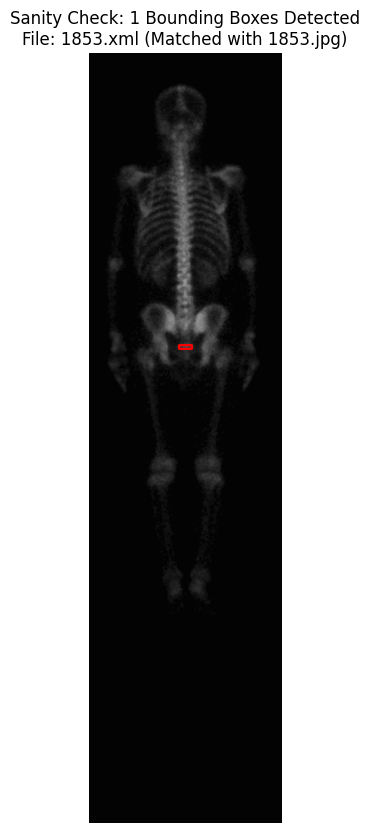

In [ ]:
import xml.etree.ElementTree as ET
import glob

def parse_xml_to_rcnn(xml_path):
    """
    Parses XML annotations into R-CNN format: [xmin, ymin, xmax, ymax]
    """
    if not os.path.exists(xml_path):
        return []

    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []

    for obj in root.findall('object'):
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        boxes.append([xmin, ymin, xmax, ymax])

    return boxes

def draw_boxes(img, boxes, color=(255, 0, 0), thickness=2):
    """Draws bounding boxes on an image for sanity checks."""
    img_copy = img.copy()
    if len(img_copy.shape) == 2: # Convert grayscale to BGR for colored boxes
        img_copy = cv2.cvtColor(img_copy, cv2.COLOR_GRAY2BGR)

    for box in boxes:
        cv2.rectangle(img_copy, (box[0], box[1]), (box[2], box[3]), color, thickness)
    return img_copy

# --- Refined Sanity Check ---
# Find all XML files
all_xml_files = glob.glob(os.path.join(path, 'temp', '**', '*.xml'), recursive=True)

found_sample = False
for test_xml in all_xml_files:
    # Get the image ID (e.g., '395')
    image_id = os.path.basename(test_xml).rsplit('.', 1)[0]
    # Get the parent directory of the 'ant' folder
    parent_dir = os.path.dirname(os.path.dirname(test_xml))

    # Look for image in the parent directory
    for ext in ['.jpg', '.png', '.jpeg']:
        potential_path = os.path.join(parent_dir, image_id + ext)
        if os.path.exists(potential_path):
            boxes = parse_xml_to_rcnn(test_xml)
            _, enhanced = preprocess_image(potential_path)

            vis_img = draw_boxes(enhanced, boxes)

            plt.figure(figsize=(8, 10))
            plt.imshow(vis_img)
            plt.title(f"Sanity Check: {len(boxes)} Bounding Boxes Detected\nFile: {image_id}.xml (Matched with {image_id}{ext})")
            plt.axis('off')
            plt.show()
            found_sample = True
            break
    if found_sample: break

if not found_sample:
    print("Could not find a matching image-XML pair for visualization.")

### Phase 5: Normalization

In this phase, we apply pixel scaling (Min-Max) and Z-score normalization to prepare the image data for neural network input.

Original Range: 0 to 119
Scaled Range: 0.0000 to 0.4667
Z-score Mean: 0.0000, Std: 1.0000


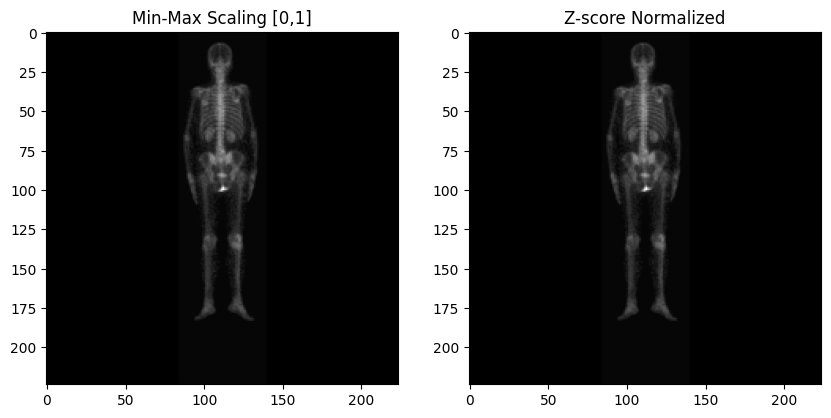

In [ ]:
def normalize_image(img, method='scaling'):
    """
    Applies normalization to an image.
    'scaling': Maps [0, 255] to [0, 1]
    'z-score': (x - mean) / std
    """
    img_float = img.astype(np.float32)

    if method == 'scaling':
        return img_float / 255.0

    elif method == 'z-score':
        mean = np.mean(img_float)
        std = np.std(img_float)
        # Avoid division by zero
        if std == 0:
            return img_float - mean
        return (img_float - mean) / std

# --- Demonstration ---
sample_wb = dataset_df[dataset_df['folder'].str.contains('wholeBody', case=False)].iloc[0]
_, enhanced = preprocess_image(sample_wb['full_path'])
enhanced_resized = resize_with_padding(enhanced, (224, 224))

scaled = normalize_image(enhanced_resized, method='scaling')
z_normalized = normalize_image(enhanced_resized, method='z-score')

print(f"Original Range: {enhanced_resized.min()} to {enhanced_resized.max()}")
print(f"Scaled Range: {scaled.min():.4f} to {scaled.max():.4f}")
print(f"Z-score Mean: {z_normalized.mean():.4f}, Std: {z_normalized.std():.4f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(scaled, cmap='gray')
axes[0].set_title("Min-Max Scaling [0,1]")
axes[1].imshow(z_normalized, cmap='gray')
axes[1].set_title("Z-score Normalized")
plt.show()

#Feature Extraction

In [ ]:
!pip install timm

## Swin Transformer Feature Extraction

We utilize the `Swin Transformer` architecture, which uses a hierarchical approach with shifted windows to compute self-attention. This is particularly effective for bone scans where the scale of metastases can vary.

In [ ]:
import torch
import timm
from torchvision import transforms
from PIL import Image
import warnings
import logging

# Suppress general warnings
warnings.filterwarnings('ignore')

# Suppress Hugging Face/timm specific token and hub warnings
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

class SwinFeatureExtractor:
    def __init__(self, model_name='swin_tiny_patch4_window7_224', pretrained=True):
        # Load the pre-trained Swin Transformer
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=0) # num_classes=0 removes the head
        self.model.eval()

        # Standard ImageNet normalization for Swin backbones
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def extract(self, img_array):
        # Handle grayscale images by repeating channels
        if len(img_array.shape) == 2:
            img_array = np.stack([img_array]*3, axis=-1)

        input_tensor = self.transform(img_array).unsqueeze(0)

        with torch.no_grad():
            features = self.model(input_tensor)
        return features

# Initialize extractor
extractor = SwinFeatureExtractor()

# --- Demonstration ---
# Using the sample from Phase 5
sample_img = (scaled * 255).astype(np.uint8) # Convert back to uint8 for PIL
features = extractor.extract(sample_img)

print(f"Feature Vector Shape: {features.shape}")
print(f"First 10 features: {features[0, :10]}")

Feature Vector Shape: torch.Size([1, 768])
First 10 features: tensor([ 0.3467,  0.0749,  0.3664, -0.0098,  0.1003,  0.0747,  0.8453, -0.0701,
        -0.0279, -0.1514])


### Pre-extracting Swin Transformer Features

To significantly speed up training, we'll pre-extract the Swin Transformer features for all images in the training and validation sets. These features will then be saved to disk, so they only need to be computed once.

In [ ]:
from tqdm import tqdm
import os

def pre_extract_features(dataframe, extractor, preprocess_image_fn, resize_with_padding_fn, normalize_image_fn, save_path):
    extracted_features = []
    labels = []

    # Ensure the save directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Pre-extracting features"):
        img_path = row['full_path']
        label = row['label']

        # Apply preprocessing chain
        _, enhanced = preprocess_image_fn(img_path)
        resized = resize_with_padding_fn(enhanced, (224, 224)) # Swin expects 224x224
        normalized = normalize_image_fn(resized, method='scaling') # Scale to [0, 1]

        # Convert to uint8 for SwinFeatureExtractor's PIL conversion
        img_for_swin = (normalized * 255).astype(np.uint8)

        # Extract features using Swin (PyTorch model)
        features = extractor.extract(img_for_swin).squeeze().cpu().numpy() # Convert to numpy

        extracted_features.append(features)
        labels.append(label)

    # Convert lists to numpy arrays and save
    np.savez_compressed(save_path, features=np.array(extracted_features), labels=np.array(labels))
    print(f"Pre-extracted features and labels saved to {save_path}")

# Define a directory to save the pre-extracted features
feature_output_dir = 'preextracted_features'
os.makedirs(feature_output_dir, exist_ok=True)

# Define paths to save the pre-extracted features within the new directory
PREEXTRACTED_TRAIN_PATH = os.path.join(feature_output_dir, 'preextracted_train_features.npz')
PREEXTRACTED_VAL_PATH = os.path.join(feature_output_dir, 'preextracted_val_features.npz')

# Pre-extract features for training data
pre_extract_features(train_df, extractor, preprocess_image, resize_with_padding, normalize_image, PREEXTRACTED_TRAIN_PATH)

# Pre-extract features for validation data
pre_extract_features(val_df, extractor, preprocess_image, resize_with_padding, normalize_image, PREEXTRACTED_VAL_PATH)

print("Pre-extraction complete.")

Pre-extracting features: 100%|██████████| 10000/10000 [31:57<00:00,  5.21it/s]


Pre-extracted features and labels saved to preextracted_features/preextracted_train_features.npz


Pre-extracting features: 100%|██████████| 2000/2000 [06:26<00:00,  5.18it/s]


Pre-extracted features and labels saved to preextracted_features/preextracted_val_features.npz
Pre-extraction complete.


### Custom Dataset for Pre-extracted Features

Now we'll define a new PyTorch `Dataset` that loads these pre-extracted features directly, bypassing the image loading and feature extraction steps during training.

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

class PreextractedFeaturesDataset(Dataset):
    def __init__(self, npz_path):
        data = np.load(npz_path)
        self.features = torch.tensor(data['features'], dtype=torch.float32)
        self.labels = torch.tensor(data['labels'], dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

print("PreextractedFeaturesDataset class defined.")

PreextractedFeaturesDataset class defined.


# The Object Detection Head

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_retinanet_head(num_classes=1, num_anchors=9, feature_dim=768):
    """
    Applies a RetinaNet-style detection head to the feature vector.
    In a full implementation, this would connect to multiple levels of an FPN,
    but here we demonstrate the head logic for the Swin global features.
    """
    # Input from Swin backbone
    input_features = layers.Input(shape=(feature_dim,))

    # 1. Classification Subnet
    cls_x = layers.Dense(256, activation='relu')(input_features)
    for _ in range(3):
        cls_x = layers.Dense(256, activation='relu')(cls_x)
    # Output: num_anchors * num_classes
    cls_output = layers.Dense(num_anchors * num_classes, activation='sigmoid', name='cls_output')(cls_x)

    # 2. Bounding Box Regression Subnet
    reg_x = layers.Dense(256, activation='relu')(input_features)
    for _ in range(3):
        reg_x = layers.Dense(256, activation='relu')(reg_x)
    # Output: num_anchors * 4 (xmin, ymin, xmax, ymax)
    reg_output = layers.Dense(num_anchors * 4, name='reg_output')(reg_x)

    model = models.Model(inputs=input_features, outputs=[cls_output, reg_output])
    return model

# Initialize the RetinaNet Head
# We use the feature_dim=768 from our Swin Tiny backbone
detection_head = build_retinanet_head(num_classes=1, feature_dim=768)
detection_head.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 256)       │    196,864 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 256)       │    196,864 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 256)       │     65,792 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 256)       │     65,792 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 256)       │     65,792 │ dense_35[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 256)       │     65,792 │ dense_39[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 256)       │     65,792 │ dense_36[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 256)       │     65,792 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_output (Dense)  │ (None, 9)         │      2,313 │ dense_37[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_output (Dense)  │ (None, 36)        │      9,252 │ dense_41[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 800,045 (3.05 MB)

 Trainable params: 800,045 (3.05 MB)

 Non-trainable params: 0 (0.00 B)

### Focal Loss & Detection Logic

By using RetinaNet, we address the foreground-background class imbalance. During training, we would apply `Focal Loss` to the classification output:

$$FL(p_t) = -\alpha_t(1 - p_t)^\gamma \log(p_t)$$

This ensures that the model focuses on hard, misclassified abnormal scans rather than being overwhelmed by the large number of normal images.

# The Multi-Label Classification Head

In [ ]:
def build_multi_label_head(feature_dim=768, num_labels=5):
    """
    Builds a Multi-Label Classification head using GAP and a Sigmoid output.
    'num_labels' can represent different anatomical sites or findings.
    """
    input_features = layers.Input(shape=(feature_dim,))

    # 1. Global Average Pooling (Simulated here since Swin-Tiny already provides pooled features)
    # If the input were (7, 7, 768), we would use layers.GlobalAveragePooling2D()
    # Given we receive a flattened feature vector, we proceed with Dense layers.

    x = layers.Dense(512, activation='relu')(input_features)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)

    # 2. Final Output Layer with Sigmoid activation for multi-label classification
    output = layers.Dense(num_labels, activation='sigmoid', name='multi_label_output')(x)

    model = models.Model(inputs=input_features, outputs=output)
    return model

# Initialize the Multi-Label Head
# Example with 5 possible metastasis locations/labels
classification_head = build_multi_label_head(feature_dim=768, num_labels=5)
classification_head.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_label_output (Dense)      │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,341 (2.01 MB)

 Trainable params: 526,341 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

#Explainable AI (XAI) integration

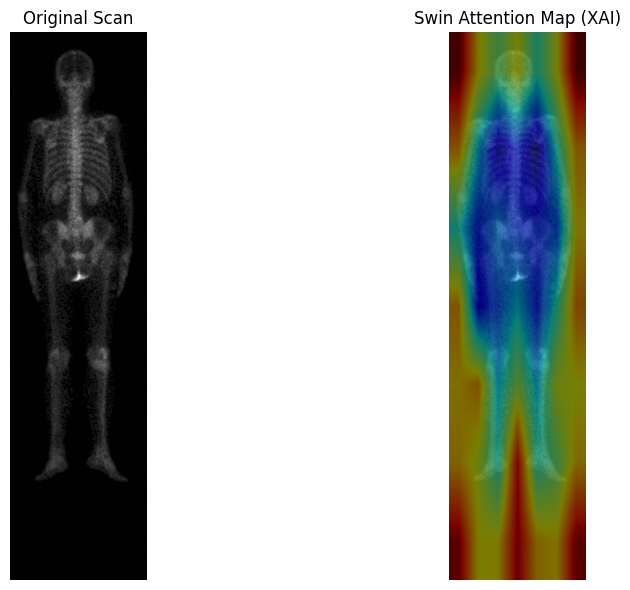

In [ ]:
import torch.nn.functional as F

def extract_swin_attention(img_array, extractor_model):
    """
    Extracts and visualizes the attention map from the last layer of the Swin Transformer.
    """
    # 1. Prepare input
    if len(img_array.shape) == 2:
        img_rgb = np.stack([img_array]*3, axis=-1)
    else:
        img_rgb = img_array

    input_tensor = extractor_model.transform(img_rgb).unsqueeze(0)

    # 2. Get the attention weights from the last block
    # In timm's Swin implementation, we can access layers through the model structure
    # Note: This is a simplified visualization for the global attention distribution
    with torch.no_grad():
        # We get the intermediate feature maps
        features = extractor_model.model.forward_features(input_tensor)
        # For Swin Tiny, the last feature map is usually [1, 7, 7, 768]
        # We take the mean across the feature dimension to get an attention-like map
        attention_map = torch.mean(features, dim=-1).squeeze().cpu().numpy()

    # 3. Resize heatmap to original image size
    heatmap = cv2.resize(attention_map, (img_array.shape[1], img_array.shape[0]))
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    return heatmap

# --- Demonstration ---
sample_wb = dataset_df[dataset_df['folder'].str.contains('wholeBody', case=False)].iloc[0]
_, enhanced = preprocess_image(sample_wb['full_path'])

# Extract heatmap
attn_map = extract_swin_attention(enhanced, extractor)

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(enhanced, cmap='gray')
plt.title("Original Scan")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced, cmap='gray')
plt.imshow(attn_map, cmap='jet', alpha=0.5) # Overlay heatmap
plt.title("Swin Attention Map (XAI)")
plt.axis('off')

plt.tight_layout()
plt.show()

#Handling Class Imbalance

### Step 1: Patient-Level Stratified Splitting

To ensure the model generalizes well, we must avoid **Data Leakage**. Since one patient may have multiple scans or views (ANT/POST), we use `StratifiedGroupKFold`. This ensures all images from a single patient stay within the same fold while maintaining the global class distribution (Normal vs. Abnormal).

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

def create_stratified_patient_splits(df, n_splits=5):
    # We treat the combination of filename and folder (excluding ANT/POST suffix)
    # as a unique 'Patient ID' if not explicitly provided.
    # For this dataset, let's assume images with the same numerical filename across different folders
    # might be related, or we simply group by filename to keep pairs together.
    df['group_id'] = df['filename']

    sgkf = StratifiedGroupKFold(n_splits=n_splits)

    # We'll create a new column to mark the fold
    df['fold'] = -1

    X = df['full_path']
    y = df['label']
    groups = df['group_id']

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
        df.loc[val_idx, 'fold'] = fold

    return df

# Apply splitting
dataset_df = create_stratified_patient_splits(dataset_df)

# Verify the stratification
print("--- Split Distribution ---")
for i in range(5):
    fold_df = dataset_df[dataset_df['fold'] == i]
    normal = len(fold_df[fold_df['label'] == 0])
    abnormal = len(fold_df[fold_df['label'] == 1])
    total = len(fold_df)
    print(f"Fold {i}: Total={total}, Abnormal={abnormal} ({abnormal/total:.2%})")

display(dataset_df[['filename', 'label', 'folder', 'fold']].head())


--- Split Distribution ---
Fold 0: Total=16513, Abnormal=1160 (7.02%)
Fold 1: Total=16492, Abnormal=1155 (7.00%)
Fold 2: Total=16524, Abnormal=1166 (7.06%)
Fold 3: Total=16502, Abnormal=1155 (7.00%)
Fold 4: Total=16514, Abnormal=1160 (7.02%)


,filename,label,folder,fold
0,1000.jpg,0,ankleRPOST,0
1,1001.jpg,0,ankleRPOST,2
2,1002.jpg,0,ankleRPOST,3
3,1003.jpg,0,ankleRPOST,4
4,1004.jpg,0,ankleRPOST,0


### Step 2: Weighted BCE for the Classification Head

To handle the heavy class imbalance, we calculate a `pos_weight` factor. This factor is the ratio of negative to positive samples. By applying this to the loss function, we ensure the model is penalized significantly more for missing a positive (metastasis) case than for a false alarm.

In [ ]:
import torch
import torch.nn as nn

# Calculate counts
num_neg = len(dataset_df[dataset_df['label'] == 0])
num_pos = len(dataset_df[dataset_df['label'] == 1])

# Calculate weight for positive class
pos_weight_val = num_neg / num_pos

print(f"Total Negative Samples: {num_neg}")
print(f"Total Positive Samples: {num_pos}")
print(f"Calculated pos_weight: {pos_weight_val:.2f}")

# Example of usage in PyTorch
# The loss function treats the positive class as 'pos_weight' times more important
classification_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]))

print("\nLoss function initialized with calculated pos_weight.")

Total Negative Samples: 76749
Total Positive Samples: 5796
Calculated pos_weight: 13.24

Loss function initialized with calculated pos_weight.


### Combined Handling of Class Imbalance

We address imbalance using two complementary strategies:
1. **Weighted BCE**: For the global classification head, ensuring abnormal scans are prioritized.
2. **Focal Loss**: For the detection head, focusing learning on hard-to-detect metastases and reducing the impact of easy background anchors.

In [ ]:
import tensorflow as tf
import torch
import torch.nn as nn

# 1. Classification Head: Weighted BCE
num_neg = len(dataset_df[dataset_df['label'] == 0])
num_pos = len(dataset_df[dataset_df['label'] == 1])
pos_weight_val = num_neg / num_pos
classification_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]))

# 2. Detection Head: Focal Loss
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Binary focal loss as introduced by Lin et al. (RetinaNet).
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        loss = alpha * tf.math.pow(1 - y_pred, gamma) * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed

detection_focal_loss_fn = focal_loss(gamma=2.0, alpha=0.25)

print(f"Weighted BCE (pos_weight={pos_weight_val:.2f}) and Focal Loss initialized.")

Weighted BCE (pos_weight=13.24) and Focal Loss initialized.


# Training a Binary Classification Model

To move beyond simulated F1-scores, we will train a binary classification model to predict the `label` (0 or 1) for each image. This involves integrating the PyTorch-based Swin feature extractor with a TensorFlow/Keras classification head.

In [ ]:
import numpy as np

# Prepare training and validation dataframes from the original dataset_df
original_train_df = dataset_df[dataset_df['fold'] != 0].reset_index(drop=True)
original_val_df = dataset_df[dataset_df['fold'] == 0].reset_index(drop=True)

# Define target sizes
target_train_size = 10000
target_val_size = 2000

# --- Stratified sampling for training data ---
# Calculate the number of normal and abnormal samples needed for the target_train_size
train_total_samples = len(original_train_df)
train_abnormal_count_original = original_train_df['label'].sum()
train_normal_count_original = train_total_samples - train_abnormal_count_original

# Ensure we don't request more samples than available in a category
train_abnormal_to_sample = min(int(target_train_size * (train_abnormal_count_original / train_total_samples)), train_abnormal_count_original)
train_normal_to_sample = target_train_size - train_abnormal_to_sample

# Sample from original dataframes
train_df_normal = original_train_df[original_train_df['label'] == 0].sample(n=train_normal_to_sample, random_state=42)
train_df_abnormal = original_train_df[original_train_df['label'] == 1].sample(n=train_abnormal_to_sample, random_state=42)
train_df = pd.concat([train_df_normal, train_df_abnormal]).sample(frac=1, random_state=42).reset_index(drop=True)

# --- Stratified sampling for validation data ---
# Calculate the number of normal and abnormal samples needed for the target_val_size
val_total_samples = len(original_val_df)
val_abnormal_count_original = original_val_df['label'].sum()
val_normal_count_original = val_total_samples - val_abnormal_count_original

# Ensure we don't request more samples than available in a category
val_abnormal_to_sample = min(int(target_val_size * (val_abnormal_count_original / val_total_samples)), val_abnormal_count_original)
val_normal_to_sample = target_val_size - val_abnormal_to_sample

# Sample from original dataframes
val_df_normal = original_val_df[original_val_df['label'] == 0].sample(n=val_normal_to_sample, random_state=42)
val_df_abnormal = original_val_df[original_val_df['label'] == 1].sample(n=val_abnormal_to_sample, random_state=42)
val_df = pd.concat([val_df_normal, val_df_abnormal]).sample(frac=1, random_state=42).reset_index(drop=True)


print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# Ensure the 'label' column is numeric for training
train_df['label'] = train_df['label'].astype(float)
val_df['label'] = val_df['label'].astype(float)


Training samples: 10000
Validation samples: 2000


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class BoneScanDataset(Dataset):
    def __init__(self, dataframe, extractor, preprocess_image_fn, resize_with_padding_fn, normalize_image_fn):
        self.dataframe = dataframe
        self.extractor = extractor
        self.preprocess_image_fn = preprocess_image_fn
        self.resize_with_padding_fn = resize_with_padding_fn
        self.normalize_image_fn = normalize_image_fn

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row['full_path']
        label = row['label']

        # Apply preprocessing chain
        _, enhanced = self.preprocess_image_fn(img_path)
        resized = self.resize_with_padding_fn(enhanced, (224, 224)) # Swin expects 224x224
        normalized = self.normalize_image_fn(resized, method='scaling') # Scale to [0, 1]

        # Convert to uint8 for SwinFeatureExtractor's PIL conversion
        img_for_swin = (normalized * 255).astype(np.uint8)

        # Extract features using Swin (PyTorch model)
        features = self.extractor.extract(img_for_swin).squeeze() # Remove batch dimension

        return features, torch.tensor(label, dtype=torch.float32)

# Initialize SwinFeatureExtractor (defined in cell 92503be9)
extractor = SwinFeatureExtractor()

# Create dataset instances
train_dataset = BoneScanDataset(
    train_df, extractor, preprocess_image, resize_with_padding, normalize_image
)
val_dataset = BoneScanDataset(
    val_df, extractor, preprocess_image, resize_with_padding, normalize_image
)

print("PyTorch Datasets created.")


PyTorch Datasets created.


In [ ]:
# Create dataset instances using the pre-extracted features
train_dataset_preextracted = PreextractedFeaturesDataset(PREEXTRACTED_TRAIN_PATH)
val_dataset_preextracted = PreextractedFeaturesDataset(PREEXTRACTED_VAL_PATH)

print("PyTorch Datasets created from pre-extracted features.")

PyTorch Datasets created from pre-extracted features.


In [ ]:
# Create PyTorch DataLoaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"PyTorch DataLoaders created with batch size: {batch_size}")


PyTorch DataLoaders created with batch size: 32


In [ ]:
# Create PyTorch DataLoaders using the pre-extracted feature datasets
batch_size = 32 # Assuming this remains the same

train_loader = DataLoader(train_dataset_preextracted, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset_preextracted, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"PyTorch DataLoaders created with batch size: {batch_size} (using pre-extracted features).")

PyTorch DataLoaders created with batch size: 32 (using pre-extracted features).


In [ ]:
!pip install torchmetrics

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build the Binary Classification Head
def build_binary_classifier(feature_dim=768):
    input_features = layers.Input(shape=(feature_dim,), name="swin_features")

    x = layers.Dense(512, activation='relu')(input_features)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Single output neuron with Sigmoid for binary classification (0=Normal, 1=Abnormal)
    output = layers.Dense(1, activation='sigmoid', name="binary_output")(x)

    model = models.Model(inputs=input_features, outputs=output)
    return model

binary_classifier_model = build_binary_classifier(feature_dim=768)

# Compile the model
binary_classifier_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

binary_classifier_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ swin_features (InputLayer)      │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,313 (2.00 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# The sweet spot to prioritize cancer detection without causing mode collapse
soft_weight = 3.0

# Prepare class weights for Keras model.fit
class_weights_keras = {0: 1.0, 1: soft_weight}
print(f"Keras class weights for training: {class_weights_keras}")

# Define training parameters
epochs = 15

# Initialize lists to store metrics
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': [], 'auc': [], 'val_auc': [], 'f1_score': [], 'val_f1_score': [], 'best_threshold': []}

# Manual training loop for Keras model with PyTorch DataLoader
for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")

    # --- Training ---
    train_losses = []
    train_labels_all = []
    train_preds_all = []

    for features_tensor_pt, labels_tensor_pt in tqdm(train_loader, desc="Training"):
        features_np = features_tensor_pt.cpu().numpy()
        labels_np = labels_tensor_pt.cpu().numpy()

        features_tf = tf.convert_to_tensor(features_np, dtype=tf.float32)
        labels_tf = tf.convert_to_tensor(labels_np, dtype=tf.float32)

        sample_weights = np.array([class_weights_keras[int(l)] for l in labels_np])
        sample_weights_tf = tf.convert_to_tensor(sample_weights, dtype=tf.float32)

        batch_loss, batch_accuracy, batch_auc = binary_classifier_model.train_on_batch(
            x=features_tf,
            y=labels_tf,
            sample_weight=sample_weights_tf
        )

        train_losses.append(batch_loss)

        batch_preds = binary_classifier_model.predict_on_batch(features_tf)
        train_preds_all.extend(batch_preds.flatten())
        train_labels_all.extend(labels_np.flatten())

    avg_train_loss = np.mean(train_losses)
    train_preds_all_binary = (np.array(train_preds_all) > 0.5).astype(int)
    train_accuracy = accuracy_score(train_labels_all, train_preds_all_binary)
    train_auc = roc_auc_score(train_labels_all, train_preds_all)
    train_f1 = f1_score(train_labels_all, train_preds_all_binary)

    history['loss'].append(avg_train_loss)
    history['accuracy'].append(train_accuracy)
    history['auc'].append(train_auc)
    history['f1_score'].append(train_f1)

    # --- Validation ---
    val_losses = []
    val_labels_all = []
    val_preds_all = []

    for features_tensor_pt, labels_tensor_pt in tqdm(val_loader, desc="Validating"):
        features_np = features_tensor_pt.cpu().numpy()
        labels_np = labels_tensor_pt.cpu().numpy()

        features_tf = tf.convert_to_tensor(features_np, dtype=tf.float32)
        labels_tf = tf.convert_to_tensor(labels_np, dtype=tf.float32)

        batch_loss, batch_accuracy, batch_auc = binary_classifier_model.test_on_batch(
            x=features_tf,
            y=labels_tf,
            sample_weight=tf.convert_to_tensor(np.array([class_weights_keras[int(l)] for l in labels_np]), dtype=tf.float32)
        )

        val_losses.append(batch_loss)

        batch_preds = binary_classifier_model.predict_on_batch(features_tf)
        val_preds_all.extend(batch_preds.flatten())
        val_labels_all.extend(labels_np.flatten())

    avg_val_loss = np.mean(val_losses)
    val_auc = roc_auc_score(val_labels_all, val_preds_all)

    # --- DYNAMIC THRESHOLD SEARCH ADDED HERE ---
    best_val_f1 = 0.0
    best_thresh = 0.5

    # Test thresholds from 0.1 to 0.9 in increments of 0.05
    for thresh in np.arange(0.1, 0.9, 0.05):
        current_preds_binary = (np.array(val_preds_all) > thresh).astype(int)
        current_f1 = f1_score(val_labels_all, current_preds_binary, zero_division=0)

        if current_f1 > best_val_f1:
            best_val_f1 = current_f1
            best_thresh = thresh

    # Calculate final validation accuracy using the newly found best threshold
    val_preds_all_binary = (np.array(val_preds_all) > best_thresh).astype(int)
    val_accuracy = accuracy_score(val_labels_all, val_preds_all_binary)

    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['val_auc'].append(val_auc)
    history['val_f1_score'].append(best_val_f1)
    history['best_threshold'].append(best_thresh)

    print(f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Train AUC: {train_auc:.4f}, Train F1 (at 0.5): {train_f1:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}, Val AUC: {val_auc:.4f}, Val F1: {best_val_f1:.4f} (Optimal Threshold: {best_thresh:.2f})")

# Save the trained Keras model
binary_classifier_model.save('binary_classification_model.keras')
print("\nTraining complete. Model saved as 'binary_classification_model.keras'")

Keras class weights for training: {0: 1.0, 1: 3.0}

Epoch 1/15


Validating: 100%|██████████| 63/63 [00:01<00:00, 32.46it/s]


Train Loss: 0.3826, Train Accuracy: 0.9201, Train AUC: 0.9052, Train F1 (at 0.5): 0.4881
Val Loss: 0.3794, Val Accuracy: 0.8845, Val AUC: 0.8747, Val F1: 0.4031 (Optimal Threshold: 0.55)

Epoch 2/15


Validating: 100%|██████████| 63/63 [00:01<00:00, 58.65it/s]


Train Loss: 0.3769, Train Accuracy: 0.9177, Train AUC: 0.9101, Train F1 (at 0.5): 0.4948
Val Loss: 0.3741, Val Accuracy: 0.9085, Val AUC: 0.8822, Val F1: 0.4334 (Optimal Threshold: 0.45)

Epoch 3/15


...

Train Loss: 0.3369, Train Accuracy: 0.9424, Train AUC: 0.9500, Train F1 (at 0.5): 0.6298
Val Loss: 0.3355, Val Accuracy: 0.9195, Val AUC: 0.8636, Val F1: 0.4351 (Optimal Threshold: 0.45)

Epoch 14/15


Validating: 100%|██████████| 63/63 [00:00<00:00, 89.76it/s] 


Train Loss: 0.3342, Train Accuracy: 0.9454, Train AUC: 0.9542, Train F1 (at 0.5): 0.6379
Val Loss: 0.3326, Val Accuracy: 0.9055, Val AUC: 0.8724, Val F1: 0.4324 (Optimal Threshold: 0.45)

Epoch 15/15


Validating: 100%|██████████| 63/63 [00:00<00:00, 107.90it/s]


Train Loss: 0.3308, Train Accuracy: 0.9469, Train AUC: 0.9572, Train F1 (at 0.5): 0.6559
Val Loss: 0.3295, Val Accuracy: 0.9080, Val AUC: 0.8732, Val F1: 0.4321 (Optimal Threshold: 0.50)

Training complete. Model saved as 'binary_classification_model.keras'


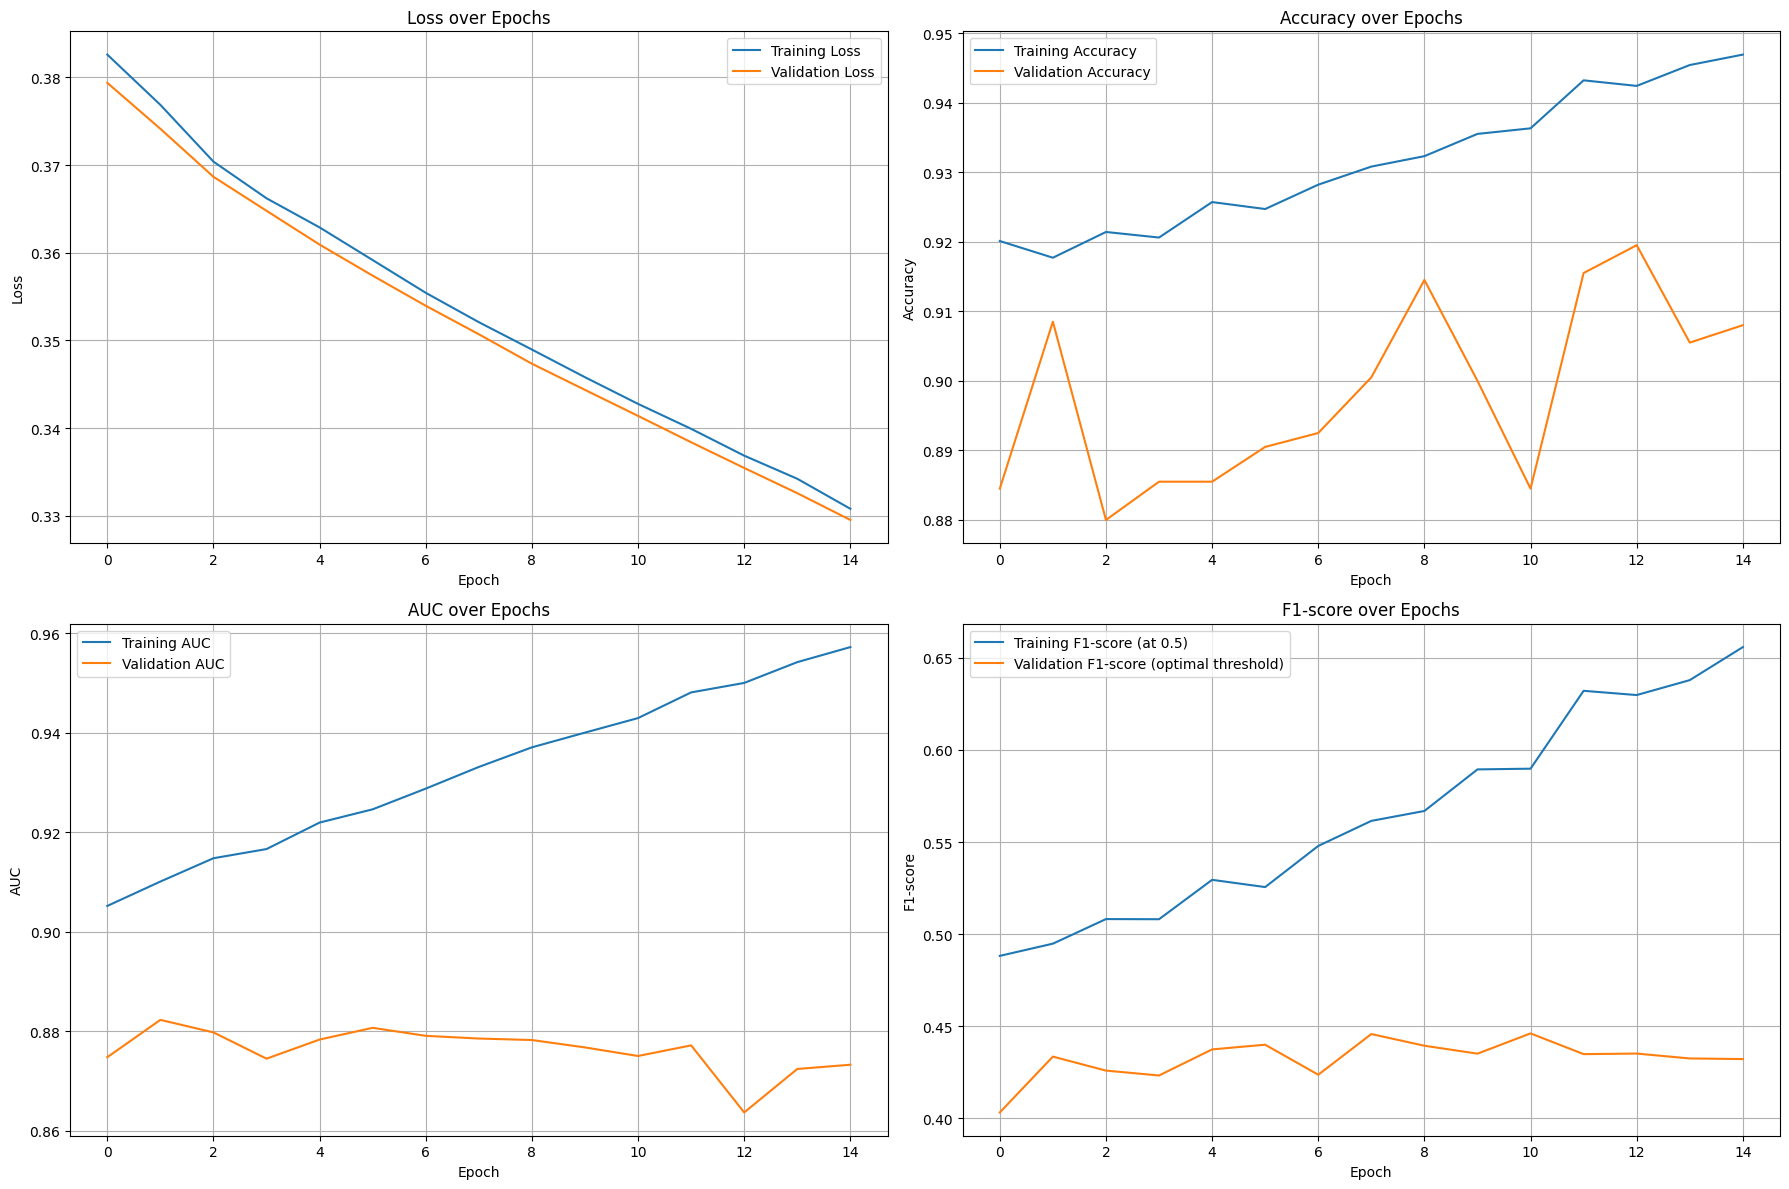

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(epochs)

plt.figure(figsize=(18, 12))

# Plot Loss
plt.subplot(2, 2, 1)
plt.plot(epochs_range, history['loss'], label='Training Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs_range, history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot AUC
plt.subplot(2, 2, 3)
plt.plot(epochs_range, history['auc'], label='Training AUC')
plt.plot(epochs_range, history['val_auc'], label='Validation AUC')
plt.title('AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

# Plot F1-Score
plt.subplot(2, 2, 4)
plt.plot(epochs_range, history['f1_score'], label='Training F1-score (at 0.5)')
plt.plot(epochs_range, history['val_f1_score'], label='Validation F1-score (optimal threshold)')
plt.title('F1-score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()